Animo la evolución de las partículas.

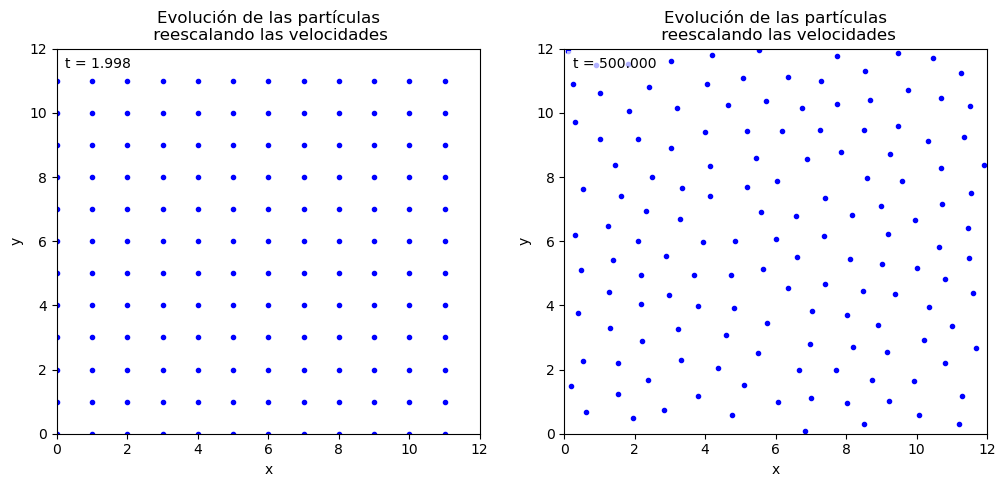

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargo los datos de las posiciones de las partícuas desde el fichero generado
Posiciones = np.loadtxt("Posiciones_Atomos_ej_6.txt")

# Defino el paso temporal
h = 0.002

# Número de frames equivalentes a 2 segundos
Num_frames = int(2 / h)

# Extraigo las posiciones x e y de cada átomo hasta i_final
# Por la estructura de la matriz, debo extraer los datos dando saltos de 2 en las columnas, ya que la X y la Y están intercaladas
x_in = Posiciones[:Num_frames, 0::2]
y_in = Posiciones[:Num_frames, 1::2]
x_fin = Posiciones[-Num_frames:, 0::2]
y_fin = Posiciones[-Num_frames:, 1::2]
# Matrices de dimensión Nx100

# Creo la figura y los ejes para la animación
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].set(xlabel="x", ylabel="y", xlim=[0, 12], ylim=[0, 12], title="Evolución de las partículas\n reescalando las velocidades")
ax[1].set(xlabel="x", ylabel="y", xlim=[0, 12], ylim=[0, 12], title="Evolución de las partículas\n reescalando las velocidades")

# Creo las líneas que representan cada átomo
line_in, = ax[0].plot([], [], color = 'blue', marker = 'o', markersize = 3, linestyle = 'None')
line_fin, = ax[1].plot([], [], color = 'blue', marker = 'o', markersize = 3, linestyle = 'None')
# Creo un texto para mostrar el tiempo en cada frame
texto_1 = ax[0].text(0.02, 0.95, "", transform=ax[0].transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
texto_2 = ax[1].text(0.02, 0.95, "", transform=ax[1].transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

# Creo la función de animación
def animate(i):

    t_in= i * h
    t_fin = 498 + (i + 1) * h

    line_in.set_data(x_in[i, :], y_in[i, :])
    line_fin.set_data(x_fin[i, :], y_fin[i, :])

    # Actualizo el texto con el tiempo correspondiente a cada frame
    texto_1.set_text(f"t = {t_in:.3f}")
    texto_2.set_text(f"t = {t_fin:.3f}") 

    return line_in, line_fin, texto_1, texto_2

# Crea una animación usando la función animate
ani = animation.FuncAnimation(fig, animate, frames = Num_frames, interval = 20, blit = True)

ani.save("Lennard_Jones_animacion_ej_6.gif", writer='pillow', dpi = 150)
# Guarda la animación como un archivo GIF usando el escritor 'pillow' y dpi es para establecer la calidad de la imagen, siendo que a mayor dpi, mayor calidad y mayor tamaño del archivo GIF generado


Calculo las fluctuaciones de la posición para una partícula cualquiera.

\begin{equation}
\nonumber

\langle (r(t) - r(t=0))^2 \rangle
\end{equation}

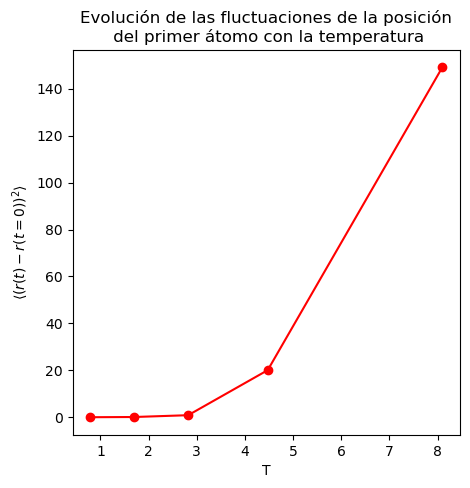

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cargo los datos de las posiciones del átomo 0 desde el fichero generado, y las velocidades de los demás
Posicion_atomo = np.loadtxt("Posicion_Atomo_Individual_ej_6.txt")
Velocidades = np.loadtxt("Velocidades_Atomos_ej_6.txt")

# Defino el paso temporal y la longitud de la caja
h = 0.002
L = 12

# Extraigo las posiciones x e y del átomo 0
x = Posicion_atomo[1:, 0]
y = Posicion_atomo[1:, 1]

x_0 = Posicion_atomo[0, 0]
y_0 = Posicion_atomo[0, 1]

# Calculo la diferencia en la posición del átomo respecto a su posición inicial
dx = x - x_0
dy = y - y_0

# Calculo r^2
r_cuadrado = dx**2 + dy**2

# Realizo los promedios en los intervalos de tiempo correspondientes a los reescalados de las velocidades, es decir, a t = 180, 270, 300 y 400 segundos
r_cuadrado_0 = np.mean(r_cuadrado[:90000])
r_cuadrado_180 = np.mean(r_cuadrado[90000:135000])
r_cuadrado_270 = np.mean(r_cuadrado[135000:150000])
r_cuadrado_300 = np.mean(r_cuadrado[150000:200000])
r_cuadrado_400 = np.mean(r_cuadrado[200000:])

# Almaceno en un array 
r_cuadrado_medio = np.array([r_cuadrado_0, r_cuadrado_180, r_cuadrado_270, r_cuadrado_300, r_cuadrado_400])

# Extraigo las velocidades v_x e v_y de los átomos
v_x = Velocidades[1:, 0::2]
v_y = Velocidades[1:, 1::2]

# Hago la media sobre las columnas, es decir, sobre los átomos, para obtener la temperatura en cada instante de tiempo 
T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1)

# Hago la media sobre los intervalos de tiempo correspondientes a los reescalados de las velocidades, es decir, a t = 180, 270, 300 y 400 segundos
T_0 = np.mean(T[:90000])
T_180 = np.mean(T[90000:135000])
T_270 = np.mean(T[135000:150000])
T_300 = np.mean(T[150000:200000])
T_400 = np.mean(T[200000:])

# Almaceno en un array
T_medio = np.array([T_0, T_180, T_270, T_300, T_400])

# Grafico la evolución de r_cuadrado en función de la temperatura
fig, ax = plt.subplots(figsize=(5, 5))

# Grafico la evolución de r_cuadrado en función de la temperatura T
ax.plot(T_medio, r_cuadrado_medio, marker = "o", color = 'red')
ax.set_xlabel("T")
ax.set_ylabel(r"$\langle(r(t) - r(t=0))^2 \rangle$")
ax.set_title("Evolución de las fluctuaciones de la posición\n del primer átomo con la temperatura")

fig.savefig("r_vs_t_ej_6.png", dpi = 150)
plt.show()

